In [2]:
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('monthly_average_BATS_cleaned.csv')

In [4]:
df.head()

,year_month,depth,Temperature,Salinity,Oxygen_1,CO2,Alkalinity,NO3_plus_NO2,NO2,PO4,Silicate,POC,PON,TOC,Bact_Enum,year,CO2_rolling,Alkalinity_rolling
0,1992-01-01,690.000000,15.565125,35.958723,225.854167,2056.258333,2398.263636,8.589375,0.083750,0.563542,8.352292,16.452188,3.523438,54.4,3.410000,1992,NaN,NaN
1,1992-02-01,585.584146,15.657915,35.998205,228.434091,2061.666667,2377.966667,8.487778,0.097381,0.556222,8.052222,13.292000,3.275000,54.4,3.951724,1992,NaN,NaN
2,1992-03-01,683.216667,15.043264,35.967208,227.029167,2062.550000,2392.100000,8.546596,0.036190,0.585745,8.768750,14.677188,3.524062,54.4,4.044444,1992,NaN,NaN
3,1992-04-01,606.393976,15.876349,36.027600,227.782222,2070.208333,2394.225000,8.256889,0.044889,0.525814,7.562000,19.444333,4.285667,54.4,4.230000,1992,NaN,NaN
4,1992-05-01,681.927778,15.662847,36.023271,228.402083,2068.016667,2392.408333,8.326667,0.008958,0.575000,7.776458,19.150000,4.015000,54.4,4.441667,1992,NaN,NaN


In [5]:
df_boost = df.drop(columns=['year_month', 'CO2_rolling', 'Alkalinity_rolling', 'year'])
df_boost.head()

,depth,Temperature,Salinity,Oxygen_1,CO2,Alkalinity,NO3_plus_NO2,NO2,PO4,Silicate,POC,PON,TOC,Bact_Enum
0,690.000000,15.565125,35.958723,225.854167,2056.258333,2398.263636,8.589375,0.083750,0.563542,8.352292,16.452188,3.523438,54.4,3.410000
1,585.584146,15.657915,35.998205,228.434091,2061.666667,2377.966667,8.487778,0.097381,0.556222,8.052222,13.292000,3.275000,54.4,3.951724
2,683.216667,15.043264,35.967208,227.029167,2062.550000,2392.100000,8.546596,0.036190,0.585745,8.768750,14.677188,3.524062,54.4,4.044444
3,606.393976,15.876349,36.027600,227.782222,2070.208333,2394.225000,8.256889,0.044889,0.525814,7.562000,19.444333,4.285667,54.4,4.230000
4,681.927778,15.662847,36.023271,228.402083,2068.016667,2392.408333,8.326667,0.008958,0.575000,7.776458,19.150000,4.015000,54.4,4.441667


df_boost head saved as 'df_boost_head.png'


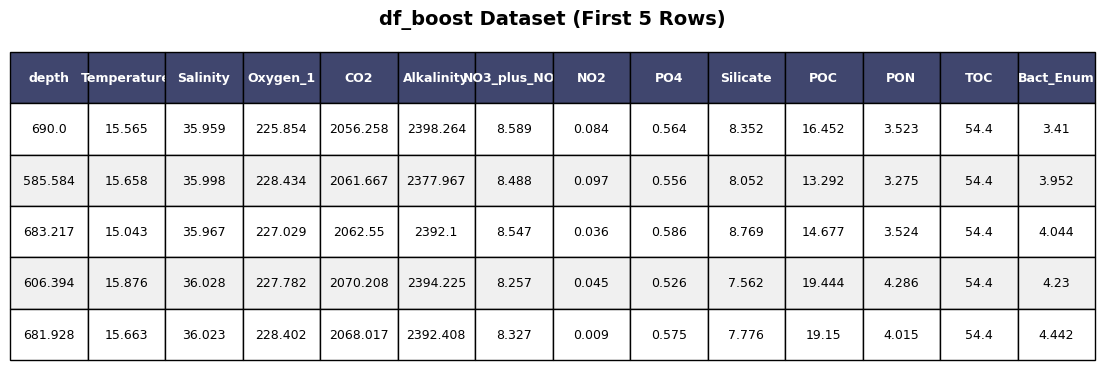

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('tight')
ax.axis('off')


rounded_data = df_boost.head().round(3).values
table = ax.table(cellText=rounded_data,
                colLabels=df_boost.columns,
                cellLoc='center',
                loc='center',
                bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)


for i in range(len(df_boost.columns)):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')


for i in range(1, 6):
    for j in range(len(df_boost.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')

plt.title('df_boost Dataset (First 5 Rows)', fontweight='bold', fontsize=14, pad=20)
plt.savefig('df_boost_head.png', dpi=300, bbox_inches='tight', facecolor='white')
print("df_boost head saved as 'df_boost_head.png'")
plt.show()

In [7]:
X = df_boost.drop(columns='Alkalinity')
y = df_boost['Alkalinity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)


X_train and X_test heads saved as 'X_train_X_test_heads.png'


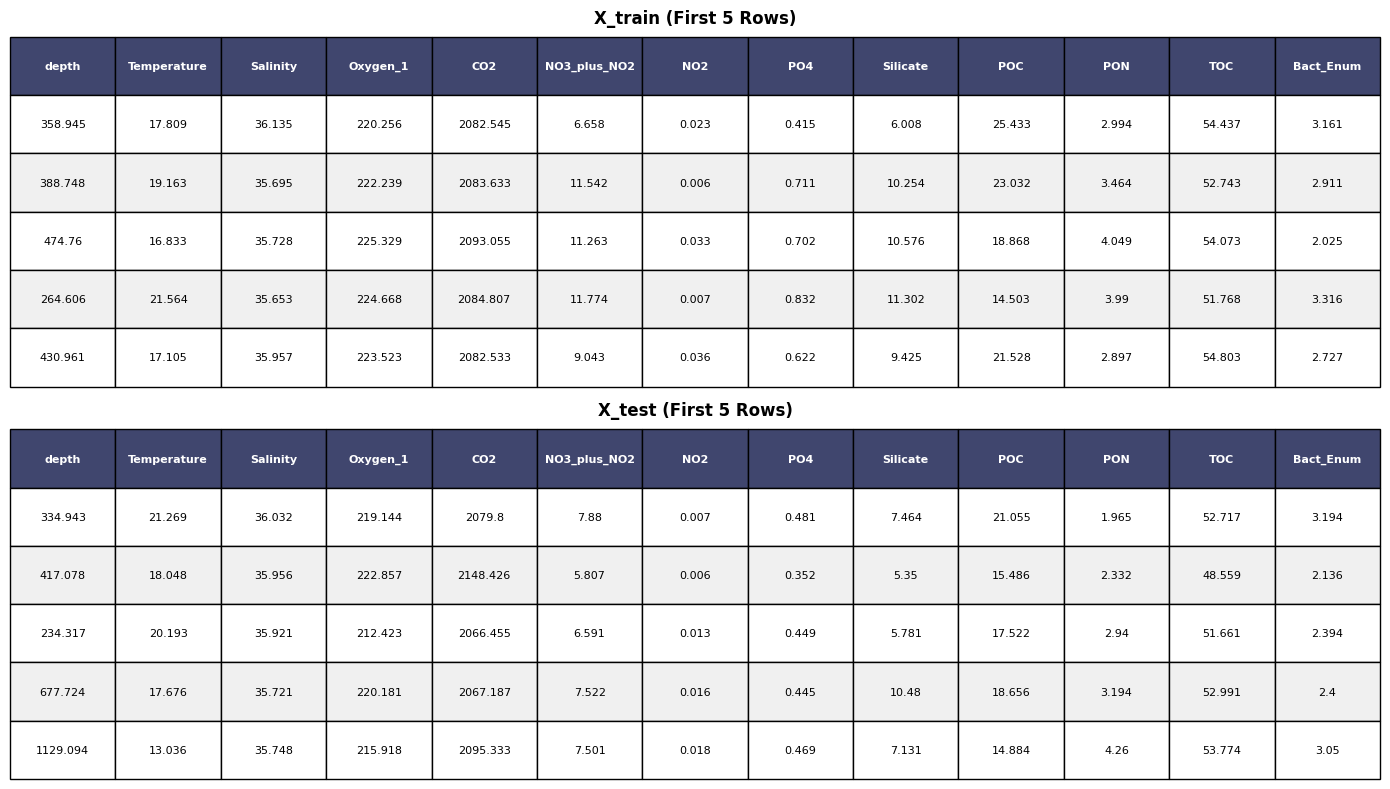

In [ ]:

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax1 = axes[0]
ax1.axis('tight')
ax1.axis('off')

rounded_X_train = X_train.head().round(3).values
table1 = ax1.table(cellText=rounded_X_train,
                   colLabels=X_train.columns,
                   cellLoc='center',
                   loc='center',
                   bbox=[0, 0, 1, 1])

table1.auto_set_font_size(False)
table1.set_fontsize(8)
table1.scale(1, 2)

for i in range(len(X_train.columns)):
    table1[(0, i)].set_facecolor('#40466e')
    table1[(0, i)].set_text_props(weight='bold', color='white')

for i in range(1, 6):
    for j in range(len(X_train.columns)):
        if i % 2 == 0:
            table1[(i, j)].set_facecolor('#f0f0f0')

ax1.set_title('X_train (First 5 Rows)', fontweight='bold', fontsize=12, pad=10)

ax2 = axes[1]
ax2.axis('tight')
ax2.axis('off')
rounded_X_test = X_test.head().round(3).values
table2 = ax2.table(cellText=rounded_X_test,
                   colLabels=X_test.columns,
                   cellLoc='center',
                   loc='center',
                   bbox=[0, 0, 1, 1])

table2.auto_set_font_size(False)
table2.set_fontsize(8)
table2.scale(1, 2)

for i in range(len(X_test.columns)):
    table2[(0, i)].set_facecolor('#40466e')
    table2[(0, i)].set_text_props(weight='bold', color='white')

for i in range(1, 6):
    for j in range(len(X_test.columns)):
        if i % 2 == 0:
            table2[(i, j)].set_facecolor('#f0f0f0')

ax2.set_title('X_test (First 5 Rows)', fontweight='bold', fontsize=12, pad=10)

plt.tight_layout()
plt.savefig('X_train_X_test_heads.png', dpi=300, bbox_inches='tight', facecolor='white')
print("X_train and X_test heads saved as 'X_train_X_test_heads.png'")

plt.show()

In [9]:
param_grid = {
    'max_depth': [1, 3, 5, 7],
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.3],
    'reg_lambda': [10**-7, 10**-5, 10**-3, 1]
}

xgb = XGBRegressor(objective='reg:squarederror', random_state=123)


grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\n" + "="*60)
print("Quick GridSearchCV Results:")
print("="*60)
print(f"Best parameters: {grid.best_params_}")
print(f"Best CV R² score: {grid.best_score_:.4f}")

y_pred = grid.best_estimator_.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"\nTest Set Performance:")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {np.sqrt(mse):.4f}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Quick GridSearchCV Results:
Best parameters: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 100, 'reg_lambda': 1}
Best CV R² score: 0.8344

Test Set Performance:
R² Score: 0.8156
MSE: 38.4609
RMSE: 6.2017

Quick GridSearchCV Results:
Best parameters: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 100, 'reg_lambda': 1}
Best CV R² score: 0.8344

Test Set Performance:
R² Score: 0.8156
MSE: 38.4609
RMSE: 6.2017


In [ ]:
best_model = grid.best_estimator_

print("Feature Importance Analysis:")
print("=" * 60)

feature_importance = best_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (sorted):")
print("-" * 40)
for idx, row in importance_df.iterrows():
    print(f"{row['Feature']:20s}: {row['Importance']:.4f}")

print("\n" + "=" * 60)
print("Best Model Parameters:")
print("=" * 60)
for param, value in grid.best_params_.items():
    print(f"{param:20s}: {value}")

print("\n" + "=" * 60)
print("Model Attributes:")
print("=" * 60)
print(f"Number of boosting rounds: {best_model.n_estimators}")
print(f"Number of features: {best_model.n_features_in_}")
print(f"Feature names: {list(best_model.feature_names_in_)}")



print("\n" + "=" * 60)
print("Comprehensive Performance Metrics:")
print("=" * 60)
print(f"R² Score:                    {r2:.4f}")
print(f"Mean Squared Error (MSE):    {mse:.4f}")
print(f"Root Mean Squared Error:     {np.sqrt(mse):.4f}")
print(f"Mean Absolute Error (MAE):   {mae:.4f}")

print("\n" + "=" * 60)
print("Cross-Validation Details:")
print("=" * 60)
print(f"Best CV Score (R²):          {grid.best_score_:.4f}")
print(f"Number of CV folds:          {grid.cv}")

cv_results = pd.DataFrame(grid.cv_results_)
print(f"\nTop 5 parameter combinations by CV score:")
print("-" * 60)
top_5 = cv_results.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
for idx, row in top_5.iterrows():
    print(f"Params: {row['params']}")
    print(f"  Mean CV Score: {row['mean_test_score']:.4f} (+/- {row['std_test_score']:.4f})")
    print()

Feature Importance Analysis:

Feature Importance (sorted):
----------------------------------------
CO2                 : 0.8032
NO2                 : 0.0388
Bact_Enum           : 0.0296
Salinity            : 0.0194
POC                 : 0.0173
NO3_plus_NO2        : 0.0152
PO4                 : 0.0144
Silicate            : 0.0137
Oxygen_1            : 0.0132
Temperature         : 0.0131
PON                 : 0.0129
depth               : 0.0093
TOC                 : 0.0000

Best Model Parameters:
learning_rate       : 0.1
max_depth           : 1
n_estimators        : 100
reg_lambda          : 1

Model Attributes:
Number of boosting rounds: 100
Number of features: 13
Feature names: [np.str_('depth'), np.str_('Temperature'), np.str_('Salinity'), np.str_('Oxygen_1'), np.str_('CO2'), np.str_('NO3_plus_NO2'), np.str_('NO2'), np.str_('PO4'), np.str_('Silicate'), np.str_('POC'), np.str_('PON'), np.str_('TOC'), np.str_('Bact_Enum')]

Comprehensive Performance Metrics:
R² Score:                 

Visualization saved as 'xgboost_feature_importance_predictions.png'


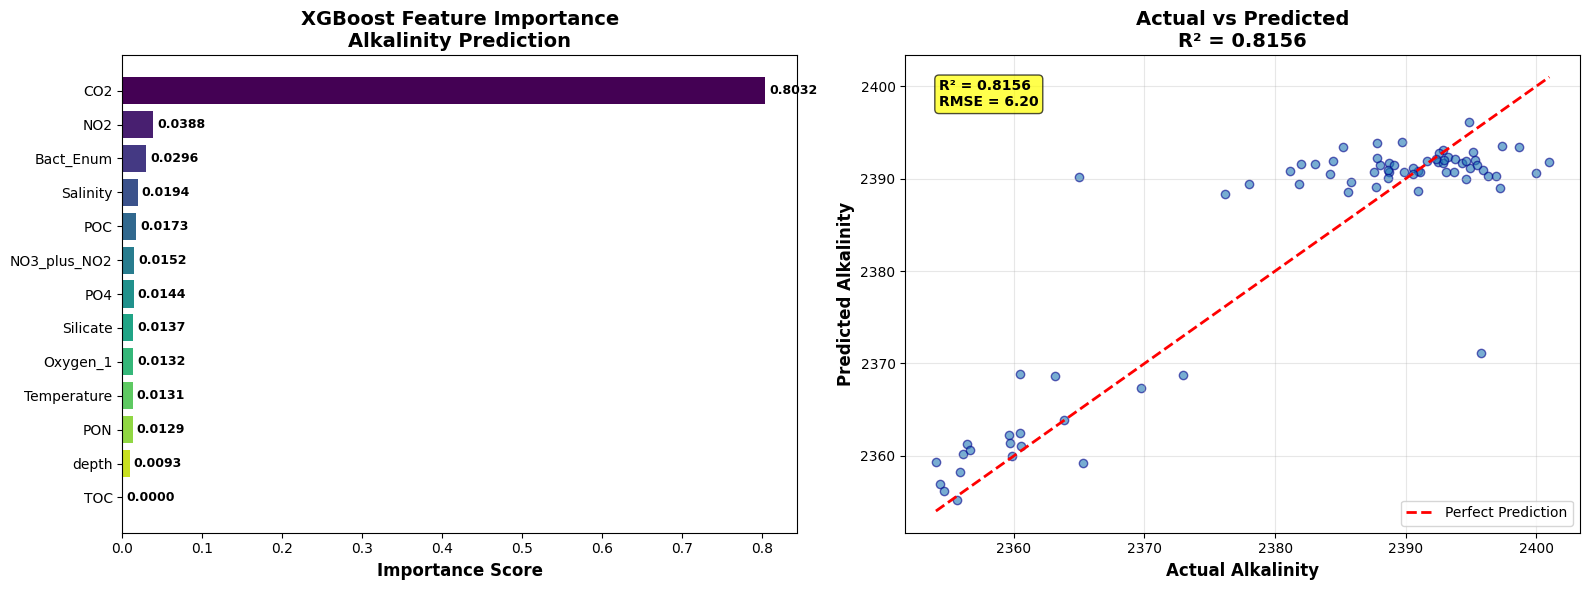

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, len(importance_df)))
bars = ax1.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
ax1.set_xlabel('Importance Score', fontweight='bold', fontsize=12)
ax1.set_title('XGBoost Feature Importance\nAlkalinity Prediction', fontweight='bold', fontsize=14)
ax1.invert_yaxis()

for bar, value in zip(bars, importance_df['Importance']):
    ax1.text(value + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{value:.4f}', ha='left', va='center', fontweight='bold', fontsize=9)

ax2 = axes[1]
ax2.scatter(y_test, y_pred, alpha=0.6, edgecolors='darkblue')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax2.set_xlabel('Actual Alkalinity', fontweight='bold', fontsize=12)
ax2.set_ylabel('Predicted Alkalinity', fontweight='bold', fontsize=12)
ax2.set_title(f'Actual vs Predicted\nR² = {r2:.4f}', fontweight='bold', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

ax2.text(0.05, 0.95, f'R² = {r2:.4f}\nRMSE = {np.sqrt(mse):.2f}', 
         transform=ax2.transAxes, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
         verticalalignment='top', fontweight='bold')

plt.tight_layout()
plt.savefig('xgboost_feature_importance_predictions.png', dpi=300, bbox_inches='tight')
print("Visualization saved as 'xgboost_feature_importance_predictions.png'")
plt.show()

In [ ]:

print("Linear Regression Model")
print("=" * 60)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\nLinear Regression Performance:")
print("-" * 40)
print(f"R² Score:                    {r2_lr:.4f}")
print(f"Mean Squared Error (MSE):    {mse_lr:.4f}")
print(f"Root Mean Squared Error:     {rmse_lr:.4f}")


coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nLinear Regression Coefficients:")
print("-" * 40)
for idx, row in coefficients.iterrows():
    print(f"{row['Feature']:20s}: {row['Coefficient']:10.4f}")

print(f"\nIntercept: {lr_model.intercept_:.4f}")

print("\n" + "=" * 60)
print("MODEL COMPARISON: XGBoost vs Linear Regression")
print("=" * 60)
print(f"{'Metric':<25} {'XGBoost':>15} {'Linear Reg':>15} {'Difference':>15}")
print("-" * 60)
print(f"{'R² Score':<25} {r2:>15.4f} {r2_lr:>15.4f} {r2 - r2_lr:>15.4f}")
print(f"{'RMSE':<25} {np.sqrt(mse):>15.4f} {rmse_lr:>15.4f} {np.sqrt(mse) - rmse_lr:>15.4f}")


if r2 > r2_lr:
    improvement = ((r2 - r2_lr) / r2_lr) * 100
    print(f"\n✓ XGBoost performs better by {improvement:.2f}% (R² improvement)")
elif r2_lr > r2:
    improvement = ((r2_lr - r2) / r2) * 100
    print(f"\n✓ Linear Regression performs better by {improvement:.2f}% (R² improvement)")
else:
    print("\n≈ Both models perform similarly")

Linear Regression Model

Linear Regression Performance:
----------------------------------------
R² Score:                    0.6628
Mean Squared Error (MSE):    70.3098
Root Mean Squared Error:     8.3851

Linear Regression Coefficients:
----------------------------------------
NO2                 :    10.4783
Salinity            :     6.1506
PO4                 :    -3.4730
PON                 :     1.8045
Temperature         :    -1.0897
Bact_Enum           :     0.7821
CO2                 :    -0.4289
Silicate            :     0.3848
NO3_plus_NO2        :     0.3450
POC                 :    -0.1322
TOC                 :    -0.0824
Oxygen_1            :     0.0307
depth               :    -0.0170

Intercept: 3075.8983

MODEL COMPARISON: XGBoost vs Linear Regression
Metric                            XGBoost      Linear Reg      Difference
------------------------------------------------------------
R² Score                           0.8156          0.6628          0.1527
RMSE        

Comparison visualization saved as 'xgboost_vs_linear_regression_comparison.png'


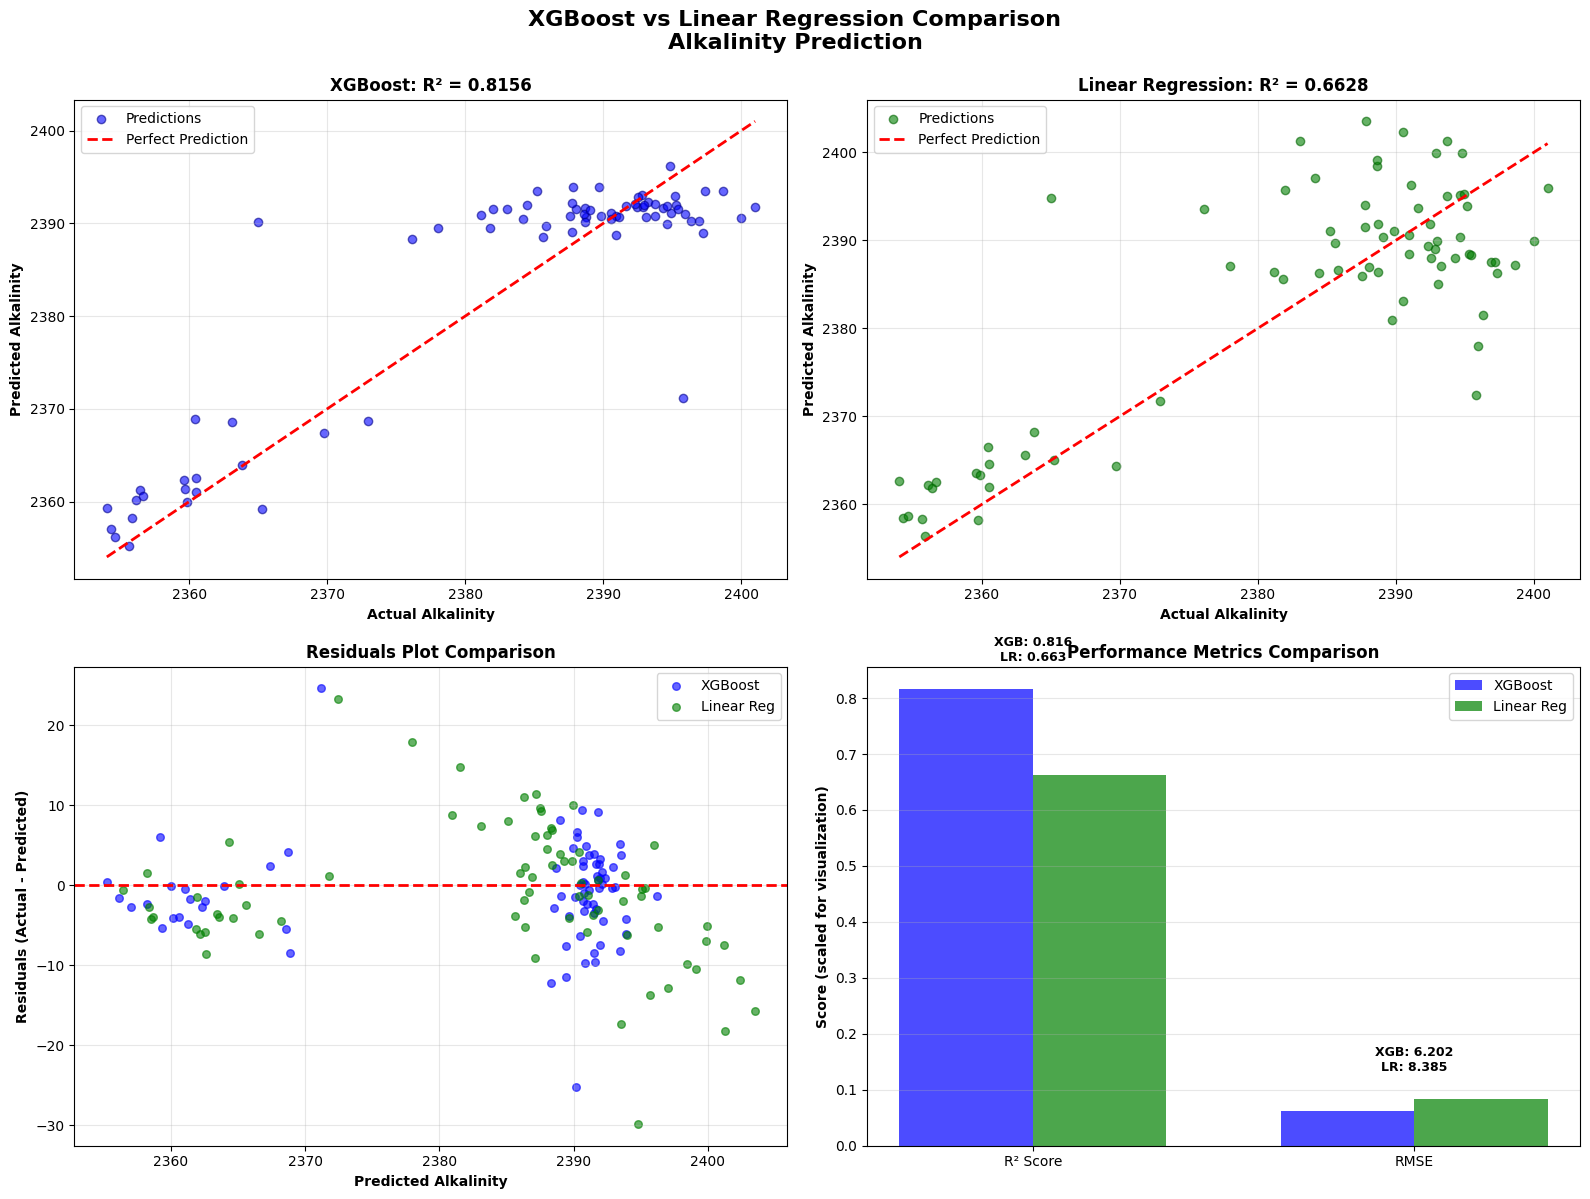

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('XGBoost vs Linear Regression Comparison\nAlkalinity Prediction', 
             fontsize=16, fontweight='bold', y=0.995)

ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred, alpha=0.6, color='blue', edgecolors='darkblue', label='Predictions')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Alkalinity', fontweight='bold')
ax1.set_ylabel('Predicted Alkalinity', fontweight='bold')
ax1.set_title(f'XGBoost: R² = {r2:.4f}', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.scatter(y_test, y_pred_lr, alpha=0.6, color='green', edgecolors='darkgreen', label='Predictions')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax2.set_xlabel('Actual Alkalinity', fontweight='bold')
ax2.set_ylabel('Predicted Alkalinity', fontweight='bold')
ax2.set_title(f'Linear Regression: R² = {r2_lr:.4f}', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
residuals_xgb = y_test - y_pred
residuals_lr = y_test - y_pred_lr

ax3.scatter(y_pred, residuals_xgb, alpha=0.6, color='blue', label='XGBoost', s=30)
ax3.scatter(y_pred_lr, residuals_lr, alpha=0.6, color='green', label='Linear Reg', s=30)
ax3.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Predicted Alkalinity', fontweight='bold')
ax3.set_ylabel('Residuals (Actual - Predicted)', fontweight='bold')
ax3.set_title('Residuals Plot Comparison', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
metrics = ['R² Score', 'RMSE']
xgb_scores = [r2, np.sqrt(mse)]
lr_scores = [r2_lr, rmse_lr]

xgb_plot = [r2, np.sqrt(mse)/100]
lr_plot = [r2_lr, rmse_lr/100]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax4.bar(x - width/2, xgb_plot, width, label='XGBoost', color='blue', alpha=0.7)
bars2 = ax4.bar(x + width/2, lr_plot, width, label='Linear Reg', color='green', alpha=0.7)

ax4.set_ylabel('Score (scaled for visualization)', fontweight='bold')
ax4.set_title('Performance Metrics Comparison', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

for i, (xgb_val, lr_val) in enumerate(zip(xgb_scores, lr_scores)):
    ax4.text(i, max(xgb_plot[i], lr_plot[i]) + 0.05, 
             f'XGB: {xgb_val:.3f}\nLR: {lr_val:.3f}',
             ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('xgboost_vs_linear_regression_comparison.png', dpi=300, bbox_inches='tight')
print("Comparison visualization saved as 'xgboost_vs_linear_regression_comparison.png'")
plt.show()